# Netflix Content Analysis

## Overview

This project analyzes the Netflix titles dataset to explore the composition, geographic distribution, genres, ratings, duration, and content additions over time.

The analysis focuses on identifying patterns in Netflix's catalog and generating insights that can support content and audience-related decisions.

## Objectives

- Analyze the distribution of Movies and TV Shows.
- Examine how content additions have changed over time.
- Identify countries with the largest representation in the catalog.
- Analyze the most common genres.
- Explore audience ratings.
- Compare movie and TV show durations.
- Identify key patterns and generate recommendations.

## Tools

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
df = pd.read_csv("../data/netflix_titles.csv", encoding = "latin-1")

## 2. Data Inspection

In [3]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
print("Missing values:")
print(df.isna().sum())

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [6]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [7]:
Missing_Values = round((df.isna().sum() / len(df))*100,2)
Missing_Values.sort_values(ascending=False)

director       29.91
country         9.44
cast            9.37
date_added      0.11
rating          0.05
duration        0.03
show_id         0.00
type            0.00
title           0.00
release_year    0.00
listed_in       0.00
description     0.00
dtype: float64

## 3. Data Cleaning

In [8]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

df["year_added"] = df["year_added"].astype("Int64")
df["month_added"] = df["month_added"].astype("Int64")

In [9]:
df[df["rating"].isin(["74 min", "84 min", "66 min"])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi...",2017,4
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...,2016,9
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...,2016,8


## 4. Value Fixing

In [10]:
mask = df["rating"].str.contains("min", na=False)
df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = np.nan

## 5. Exploratory Analysis

### 5.1 Movies vs TV Shows

In [11]:
Amount_Type= df["type"].value_counts()
Porcentage_Type = (df["type"].value_counts(normalize=True) * 100).round(2)

print(f"Amount: {Amount_Type}\n\n"
      f"Porcentage: {Porcentage_Type}\n\n")


Amount: type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Porcentage: type
Movie     69.62
TV Show   30.38
Name: proportion, dtype: float64




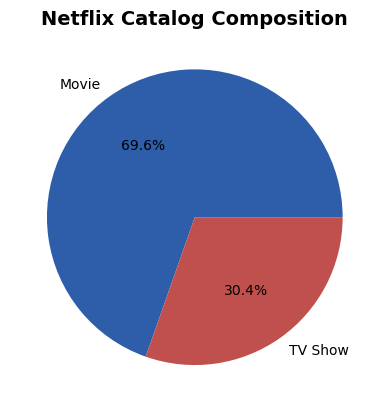

In [12]:
Amount_Type.plot(kind="pie", autopct="%1.1f%%", colors=["#2E5EAA", "#C0504D"])
plt.title("Netflix Catalog Composition", fontsize=14, fontweight= "bold")
plt.ylabel("")
plt.show()

### Key Finding

Movies represent 69.6% of the Netflix catalog, while TV Shows account for 30.4%.

### 5.2 Content Added Over Time

In [13]:
Titles_Per_Year = df.groupby("year_added")["title"].count().reset_index()
Titles_Per_Year

,year_added,title
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,10
6,2014,23
7,2015,73
8,2016,418
9,2017,1164


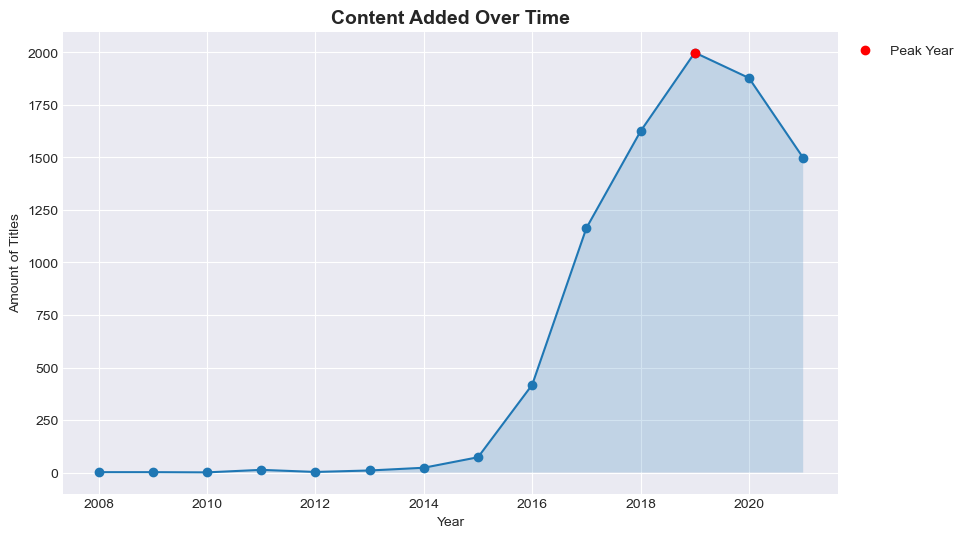

In [14]:
plt.style.use("seaborn-v0_8-darkgrid")
plt.figure(figsize=(10,6))

max_row = Titles_Per_Year.loc[Titles_Per_Year["title"].idxmax()]

plt.plot(Titles_Per_Year["year_added"], Titles_Per_Year["title"], marker ="o")
plt.fill_between(Titles_Per_Year["year_added"], Titles_Per_Year["title"], alpha=0.2)
plt.scatter(max_row["year_added"],max_row["title"], color="red", zorder=5, label="Peak Year")

plt.title("Content Added Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Amount of Titles")
plt.grid(True)
plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.show()

### Key Finding

Content additions peaked in 2019, followed by a decline in 2020 and 2021.

### 5.3 Geographic Distribution

In [15]:
Titles_Per_Country = df["country"].str.split(", ")
Titles_Per_Country = Titles_Per_Country.explode()
Titles_Per_Country =  Titles_Per_Country.value_counts()
Titles_Per_Country

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
                  ... 
Bermuda              1
Ecuador              1
Armenia              1
Mongolia             1
Montenegro           1
Name: count, Length: 127, dtype: int64

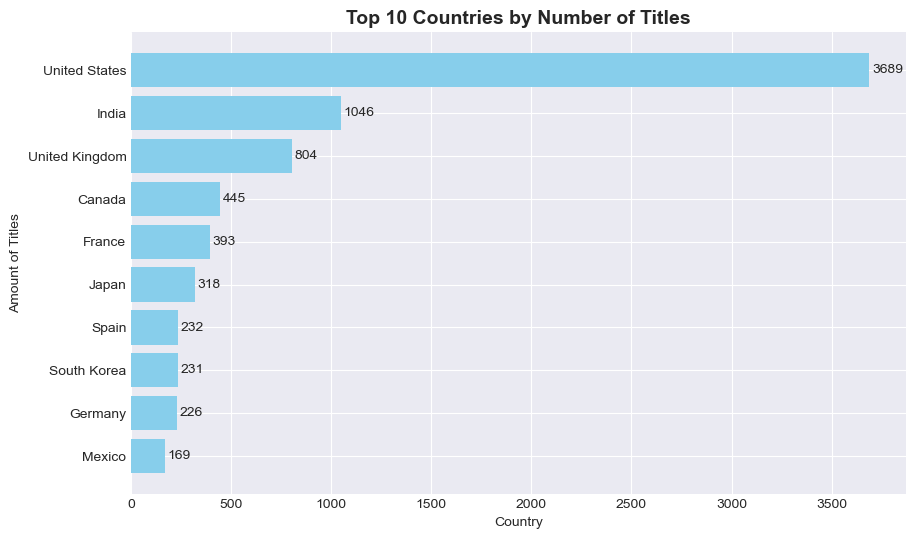

In [16]:
Top10_Countries = Titles_Per_Country.head(10)

plt.figure(figsize=(10,6))
bars = plt.barh(Top10_Countries.index, Top10_Countries.values, color="skyblue")
plt.bar_label(bars, padding = 2)

plt.title("Top 10 Countries by Number of Titles", fontsize=14, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Amount of Titles")

plt.gca().invert_yaxis()
plt.show()


### Key Finding

The United States has the strongest representation in the Netflix catalog.

### 5.4 Genre Distribution

In [17]:
Genres_Per_Titles = df["listed_in"].str.split(", ")
Genres_Per_Titles = Genres_Per_Titles.explode()
Genres_Per_Titles =  Genres_Per_Titles.value_counts()
Genres_Per_Titles

listed_in
International Movies            2752
Dramas                          2427
Comedies                        1674
International TV Shows          1351
Documentaries                    869
Action & Adventure               859
TV Dramas                        763
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
TV Comedies                      581
Thrillers                        577
Crime TV Shows                   470
Kids' TV                         451
Docuseries                       395
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 253
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     176
Spanish-Language TV Shows        174
TV Action & Adventure            168
Korean TV Shows             

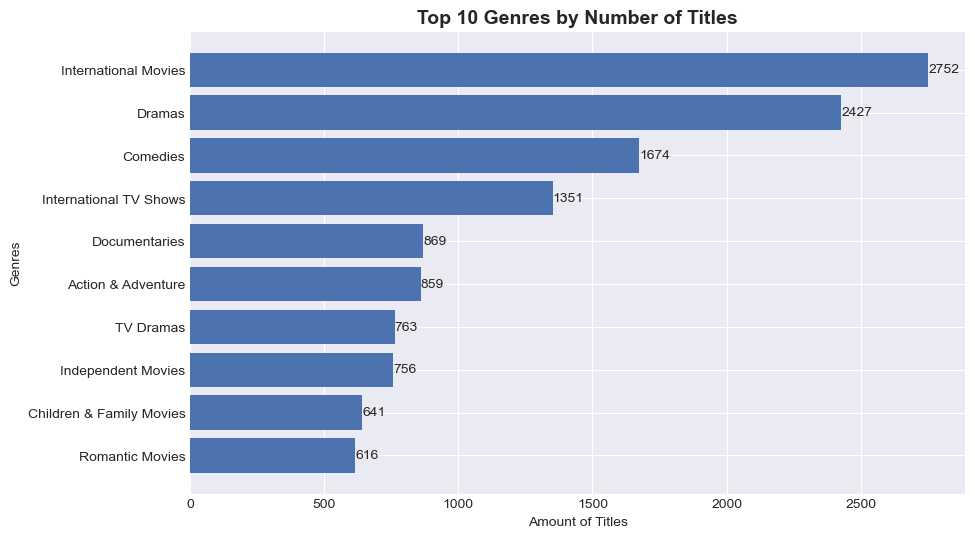

In [18]:
Top10_Genres = Genres_Per_Titles.head(10)

plt.figure(figsize=(10,6))
bars = plt.barh(Top10_Genres.index, Top10_Genres.values, color="#4C72B0")
plt.bar_label(bars)

plt.title("Top 10 Genres by Number of Titles", fontsize=14, fontweight="bold")
plt.xlabel("Amount of Titles")
plt.ylabel("Genres")
plt.gca().invert_yaxis()
plt.show()

### Key Finding

International Movies, Dramas, and Comedies are the most represented genres in the dataset.

### 5.5 Content Ratings

In [19]:
Rating_Count = df["rating"].value_counts()
Rating_Count

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

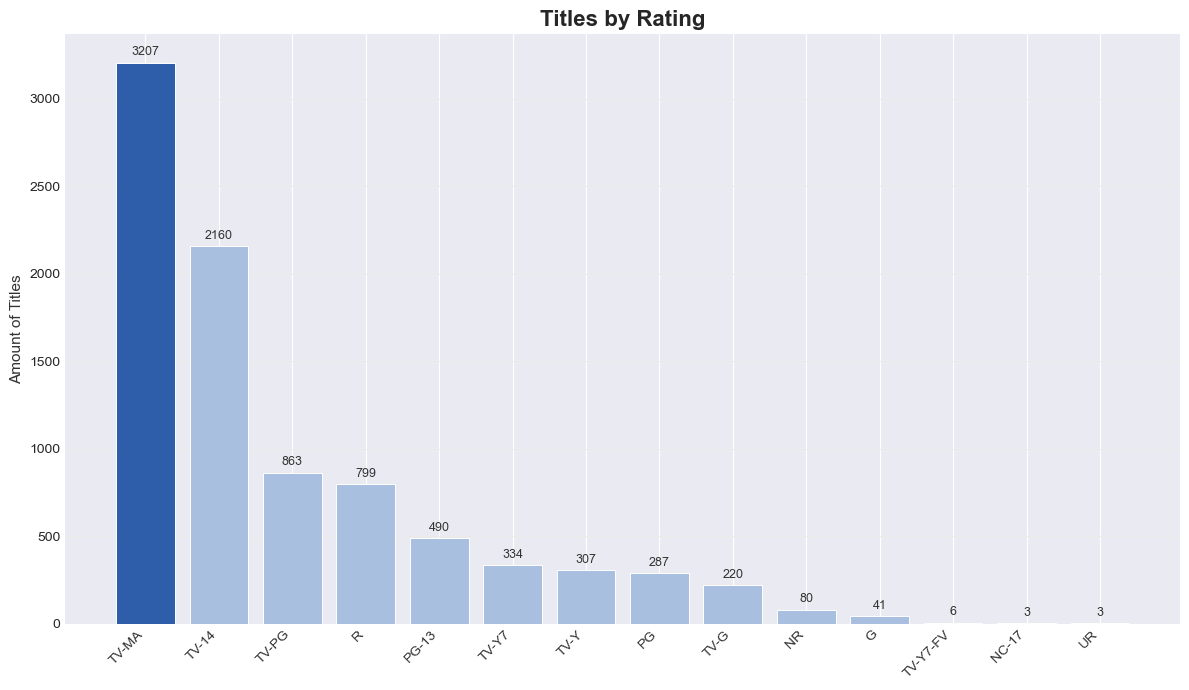

In [20]:
colors =["#2E5EAA"] + ["#A8BFE0"] * (len(Rating_Count)-1)

fig,ax = plt.subplots(figsize=(12,7))
bars = ax.bar(Rating_Count.index, Rating_Count.values, color = colors, edgecolor="white", linewidth=0.7)

ax.bar_label(bars, padding=3, fontsize=9, color="#333333")
ax.set_title("Titles by Rating", fontsize=16, fontweight="bold")

ax.set_xlabel("")
ax.set_ylabel("Amount of Titles", fontsize=11, color="#333333")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

ax.yaxis.grid(True, color="#EAEAEA", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", rotation=45, colors="#333333")

plt.setp(ax.get_xticklabels(), ha="right")

plt.tight_layout()
plt.show()



## Ratings
TV-MA is the most common rating, indicating a strong presence of mature-rated content.

### 5.6 Content Duration

In [21]:
Movies_Duration = df[df["type"] == "Movie"]["duration"].value_counts().reset_index()
Movies_Duration.columns = ["movie duration", "count"]

Series_Duration = df[df["type"] == "TV Show"]["duration"].value_counts().reset_index()
Series_Duration.columns = ["tv show duration", "count"]

Comparison_Table = pd.DataFrame({
    "Movie Duration": Movies_Duration["movie duration"],
    "Count Movies": Movies_Duration["count"],
    "Series Duration": Series_Duration["tv show duration"],
    "Count Series": Series_Duration["count"]
})
Comparison_Table.head(20)

,Movie Duration,Count Movies,Series Duration,Count Series
0,90 min,152,1 Season,"1,793.00"
1,94 min,146,2 Seasons,425.00
2,97 min,146,3 Seasons,199.00
3,93 min,146,4 Seasons,95.00
4,91 min,144,5 Seasons,65.00
5,95 min,137,6 Seasons,33.00
6,96 min,130,7 Seasons,23.00
7,92 min,129,8 Seasons,17.00
8,102 min,122,9 Seasons,9.00
9,98 min,120,10 Seasons,7.00


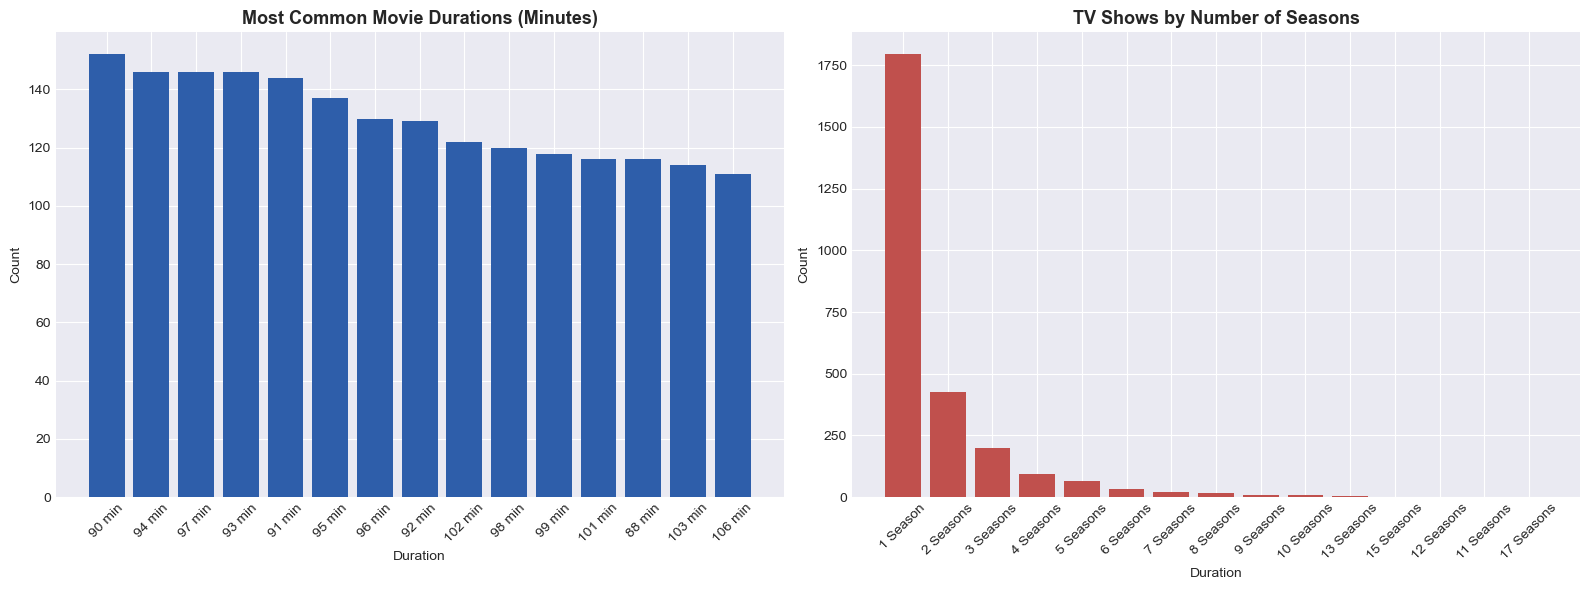

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(Movies_Duration["movie duration"].head(15), Movies_Duration["count"].head(15), color="#2E5EAA")
axes[0].set_title("Most Common Movie Durations (Minutes)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Duration")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(Series_Duration["tv show duration"], Series_Duration["count"], color="#C0504D")
axes[1].set_title("TV Shows by Number of Seasons", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Duration")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Key Finding

### Movies
Movies have a median duration of 98 minutes, with most titles lasting around 1–2 hours.

### TV Shows Duration
Most TV Shows have 1–2 seasons, with a median of 1 season.

## 6. Additional Analysis

In [23]:
Movies_Trough_Time = df[df["type"] == "Movie"]["year_added"].value_counts().reset_index()
Movies_Trough_Time.columns = ["year_added", "count"]

Series_Trough_Time = df[df["type"] == "TV Show"]["year_added"].value_counts().reset_index()
Series_Trough_Time.columns = ["year_added", "count"]

Types_Trough_Time = pd.DataFrame({
    "Year added(Movies) ": Movies_Trough_Time["year_added"],
    "Movie Counts": Movies_Trough_Time["count"],
    "Year added(TV Shows)": Series_Trough_Time ["year_added"],
    "Count Series": Series_Trough_Time["count"]
})
Types_Trough_Time

,Year added(Movies),Movie Counts,Year added(TV Shows),Count Series
0,2019,1424,2020,594
1,2020,1284,2019,575
2,2018,1237,2021,505
3,2021,993,2018,388
4,2017,839,2017,325
5,2016,253,2016,165
6,2015,56,2015,17
7,2014,19,2014,4
8,2011,13,2013,4
9,2013,6,2008,1


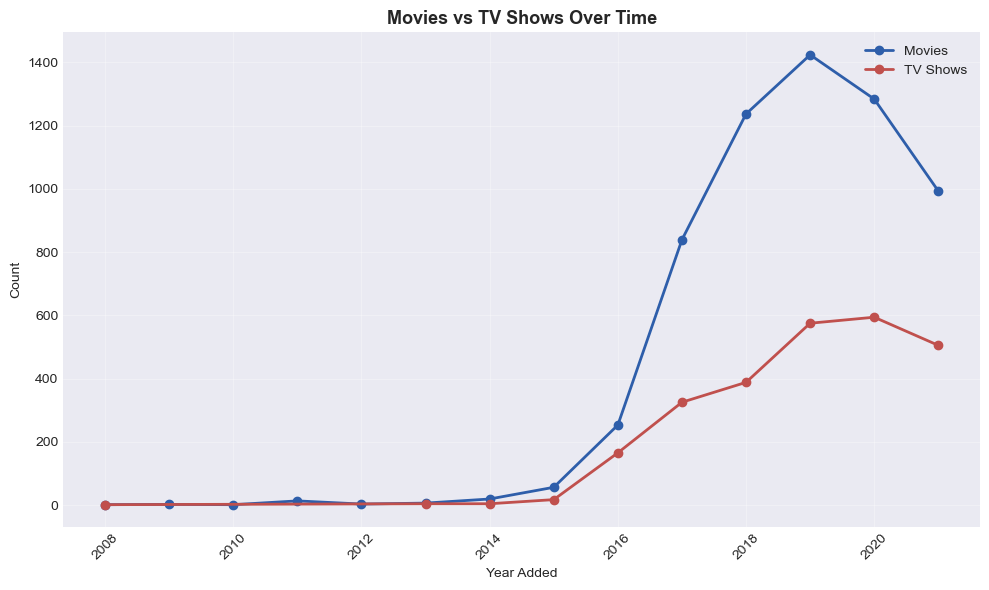

In [26]:
plt.figure(figsize=(10, 6))
movies_per_year = df[df["type"] == "Movie"]["year_added"].value_counts().sort_index()
series_per_year = df[df["type"] == "TV Show"]["year_added"].value_counts().sort_index()

plt.plot(movies_per_year.index, movies_per_year.values, marker='o', 
         color="#2E5EAA", label='Movies', linewidth=2)
plt.plot(series_per_year.index, series_per_year.values, marker='o', 
         color="#C0504D", label='TV Shows', linewidth=2)

plt.title("Movies vs TV Shows Over Time", fontsize=13, fontweight="bold")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
Countries_Alone = df["country"].str.split(", ").explode()
Genres_Alone = df["listed_in"].str.split(", ").explode()

Country_Genre = pd.merge(Countries_Alone, Genres_Alone, left_index=True, right_index=True)
Country_Genre.columns = ["country", "genre"]

Variaty_Genre = Country_Genre.groupby("country")["genre"].nunique().reset_index()
Variaty_Genre.columns = ["Country", "Variaty"]
Variaty_Genre = Variaty_Genre.sort_values("Variaty", ascending=False)
Variaty_Genre


## 7. Key Insights

## 1. Catalog composition
Netflix's catalog leans heavily toward movies (69.6%) over TV shows (30.4%), suggesting a historical strategy favoring single-format content over episodic series.

## 2. Growth and slowdown
Content additions peaked in 2019, followed by a decline in 2020 and 2021. The dataset alone does not establish the cause of this decline, so external factors would need to be investigated separately.

## 3. Geographic concentration
The United States dominates the catalog with 3,689 titles, followed by India (1,046) and the United Kingdom (804). This shows that, despite being a global platform, content remains heavily concentrated in specific markets, with the U.S. representing a disproportionately large share compared to the other 127 countries present.

## 4. Predominant genres
"International Movies," "Dramas," and "Comedies" lead the catalog. The strong presence of "International Movies" (2,752) reflects an effort to diversify content beyond purely U.S. productions, although the country-level data shows that this diversity is still limited in actual volume.

## 5. Audience rating
TV-MA is the most common rating (3,207 titles), indicating that the catalog skews mostly toward mature/adult audiences, well above family or children's content (TV-Y, TV-G, G combined account for far fewer titles).

## 6. Duration
Movies have a median runtime of 98 minutes (ranging from 3 to 312 min), consistent with industry standards. TV shows, on the other hand, tend to have few seasons: the median is just 1 season, suggesting Netflix favors limited formats (miniseries or short-run shows) over long-running series.

## 7. Data quality
The director column has the highest percentage of missing values (29.91%), followed by country (9.44%) and cast (9.37%). This is worth noting as it limits deeper analysis around directors or casting, and should be mentioned as a dataset limitation.

## 8. Recommendations

### Evaluate TV Show Season Length
Most TV Shows in the dataset have only 1–2 seasons. Netflix could investigate whether this pattern is driven by content strategy, miniseries formats, or early cancellations before deciding whether longer-running series should be prioritized.

## Diversify the catalog by country:
The strong concentration in the United States, India, and the United Kingdom leaves room for growth in underrepresented markets, especially if the platform aims to expand in regions like Latin America or Africa, where title volume is considerably lower.

## Evaluate the rating balance:
With TV-MA dominating the catalog, expanding content offerings for younger audiences (TV-Y7, TV-G) could help attract family-oriented subscribers, a segment currently underserved based on the data.

## Improve data integrity for future versions:
The near-30% absence of values in director limits analysis related to creative talent. At the data collection level, it's recommended to complete this information for more robust future analyses.

## Investigate the post-2019 decline: 
It would be worth cross-referencing this data with external factors (such as the pandemic) to understand whether the slowdown in content additions was a strategic decision or a consequence of factors outside the platform's control.

## 9. Conclusion

This analysis shows that Netflix's catalog is heavily composed of Movies, with strong representation from the United States and a significant presence of International Movies, Dramas, and Comedies.

Content additions increased substantially until 2019 before declining in the following years. The catalog also contains a large proportion of mature-rated content, while most TV Shows have relatively few seasons.

Overall, the analysis highlights several patterns in Netflix's content strategy while also showing limitations in the dataset, particularly missing information related to directors, countries, and cast.